# Data Mining Project 10: Social Media Trend Analysis

This project analyzes social media posts to identify **trending topics, public interests, and engagement patterns**.

### Tasks
1. Collect social media dataset.
2. Clean and preprocess text data.
3. Analyze trending topics.
4. Identify public interests.
5. Prepare analytical visualizations.

**Dataset:** Social Media Trend 2024  
**Source:** Kaggle  
**Method:** Text preprocessing, hashtag frequency analysis, keyword analysis, engagement analysis, and visualization.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

## 2. Collect Social Media Dataset

In [2]:
path = kagglehub.dataset_download("muskantariq/social-media-trend-2024")

print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 652/652 [00:00<00:00, 720kB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/muskantariq/social-media-trend-2024/versions/1
Files: ['social_media_trends.csv']


In [3]:
# Locate the CSV file automatically
csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

CSV files found: ['social_media_trends.csv']


,Hashtag,Tweet,User,Date,Likes,Retweets
0,#AI,AI is revolutionizing every industry!,@user1,2024-12-10,150,50
1,#DataScience,"Data Science is the future, and it's here now.",@user2,2024-12-11,200,70
2,#Python,Learning Python is the best decision I ever made.,@user3,2024-12-12,300,90
3,#MachineLearning,Machine Learning is at the heart of modern AI.,@user4,2024-12-13,400,120
4,#DeepLearning,Deep Learning is making breakthroughs every day.,@user5,2024-12-14,250,80


## 3. Explore the Dataset

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (10, 6)

Column names:
['Hashtag', 'Tweet', 'User', 'Date', 'Likes', 'Retweets']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Hashtag   10 non-null     object
 1   Tweet     10 non-null     object
 2   User      10 non-null     object
 3   Date      10 non-null     object
 4   Likes     10 non-null     int64 
 5   Retweets  10 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 612.0+ bytes


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hashtag,10,8,#AI,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tweet,10,10,AI is revolutionizing every industry!,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User,10,10,@user1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,10,10,2024-12-10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Likes,10.0,NaN,NaN,NaN,315.0,147.591779,150.0,205.0,275.0,387.5,600.0
Retweets,10.0,NaN,NaN,NaN,97.5,41.315184,50.0,71.25,85.0,115.0,180.0


## 4. Clean and Preprocess Text Data

In [7]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['hashtag', 'tweet', 'user', 'date', 'likes', 'retweets']


In [8]:
# Remove duplicate rows and rows without tweet text
df = df.drop_duplicates()

df = df.dropna(subset=["tweet", "hashtag"])

# Convert text fields to strings
df["tweet"] = df["tweet"].astype(str)
df["hashtag"] = df["hashtag"].astype(str)

# Clean tweet text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z0-9#\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_tweet"] = df["tweet"].apply(clean_text)

# Convert date column if available
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Shape after preprocessing:", df.shape)
df[["tweet", "clean_tweet", "hashtag"]].head()

Shape after preprocessing: (10, 7)


,tweet,clean_tweet,hashtag
0,AI is revolutionizing every industry!,ai is revolutionizing every industry,#AI
1,"Data Science is the future, and it's here now.",data science is the future and its here now,#DataScience
2,Learning Python is the best decision I ever made.,learning python is the best decision i ever made,#Python
3,Machine Learning is at the heart of modern AI.,machine learning is at the heart of modern ai,#MachineLearning
4,Deep Learning is making breakthroughs every day.,deep learning is making breakthroughs every day,#DeepLearning


## 5. Analyze Trending Topics

In [9]:
# Count hashtags to identify the most frequently discussed topics
hashtags = (
    df["hashtag"]
    .str.lower()
    .str.replace("#", "", regex=False)
    .str.split()
    .explode()
    .str.strip()
)

hashtags = hashtags[hashtags != ""]

trending_topics = hashtags.value_counts().head(10)

print("Top 10 Trending Topics:")
print(trending_topics)

Top 10 Trending Topics:
hashtag
ai                 2
python             2
datascience        1
machinelearning    1
deeplearning       1
bigdata            1
analytics          1
tech               1
Name: count, dtype: int64


## 6. Identify Public Interests

In [10]:
# Extract useful words from tweets
stop_words = {
    "the", "and", "for", "that", "this", "with", "from", "are",
    "was", "were", "have", "has", "had", "you", "your", "our",
    "they", "their", "about", "what", "when", "where", "which",
    "will", "would", "could", "should", "into", "just", "more",
    "than", "then", "them", "there", "here", "its", "it's",
    "but", "not", "all", "can", "get", "got", "out", "who",
    "how", "why", "too", "very", "his", "her", "she", "him",
    "our", "been", "being", "also"
}

words = (
    df["clean_tweet"]
    .str.replace("#", " ", regex=False)
    .str.split()
    .explode()
)

words = words[
    words.str.len().gt(2) &
    ~words.isin(stop_words)
]

public_interests = words.value_counts().head(15)

print("Most Discussed Public Interests / Keywords:")
print(public_interests)

Most Discussed Public Interests / Keywords:
clean_tweet
data               3
learning           3
every              2
python             2
revolutionizing    1
industry           1
science            1
now                1
future             1
best               1
decision           1
ever               1
made               1
machine            1
heart              1
Name: count, dtype: int64


## 7. Analyze Engagement

In [11]:
# Create an engagement score from likes and retweets
df["engagement"] = df["likes"] + df["retweets"]

top_engaging_posts = (
    df.sort_values("engagement", ascending=False)
    [["tweet", "hashtag", "likes", "retweets", "engagement"]]
    .head(10)
)

print("Top 10 Most Engaging Posts:")
top_engaging_posts

Top 10 Most Engaging Posts:


,tweet,hashtag,likes,retweets,engagement
8,Python is the most versatile programming langu...,#Python,600,180,780
7,AI is changing the way we interact with the wo...,#AI,500,150,650
3,Machine Learning is at the heart of modern AI.,#MachineLearning,400,120,520
9,Tech trends to watch out for in 2024!,#Tech,350,100,450
2,Learning Python is the best decision I ever made.,#Python,300,90,390
4,Deep Learning is making breakthroughs every day.,#DeepLearning,250,80,330
6,Analytics transforms raw data into actionable ...,#Analytics,220,75,295
1,"Data Science is the future, and it's here now.",#DataScience,200,70,270
5,Big Data helps make sense of large-scale infor...,#BigData,180,60,240
0,AI is revolutionizing every industry!,#AI,150,50,200


In [12]:
# Average engagement by hashtag
hashtag_engagement = (
    df.groupby("hashtag")["engagement"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top Hashtags by Average Engagement:")
print(hashtag_engagement)

Top Hashtags by Average Engagement:
hashtag
#Python             585.0
#MachineLearning    520.0
#Tech               450.0
#AI                 425.0
#DeepLearning       330.0
#Analytics          295.0
#DataScience        270.0
#BigData            240.0
Name: engagement, dtype: float64


## 8. Prepare Analytical Visualizations

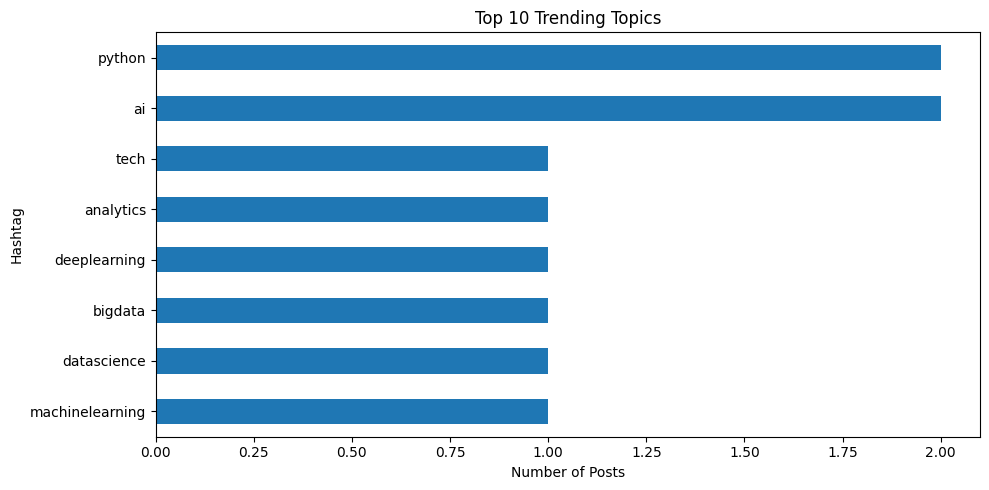

In [13]:
plt.figure(figsize=(10, 5))

trending_topics.sort_values().plot(kind="barh")

plt.title("Top 10 Trending Topics")
plt.xlabel("Number of Posts")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

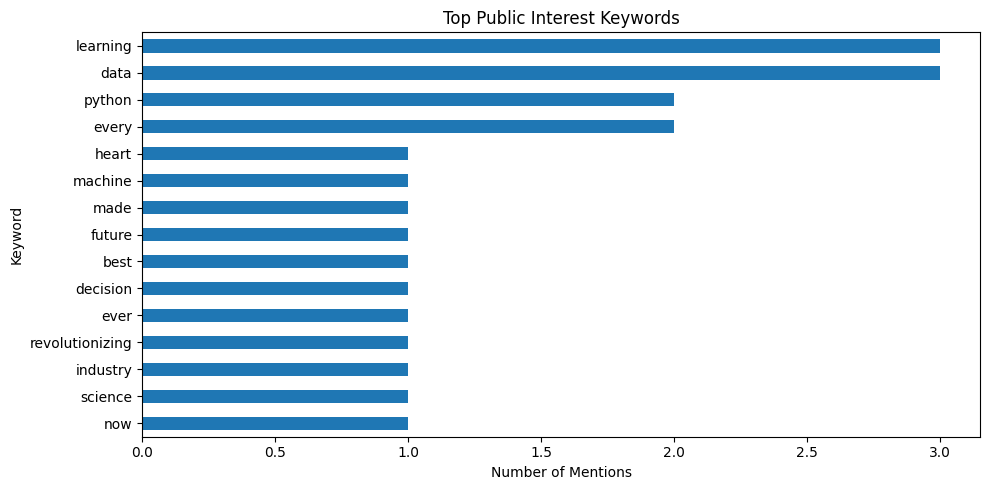

In [14]:
plt.figure(figsize=(10, 5))

public_interests.sort_values().plot(kind="barh")

plt.title("Top Public Interest Keywords")
plt.xlabel("Number of Mentions")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

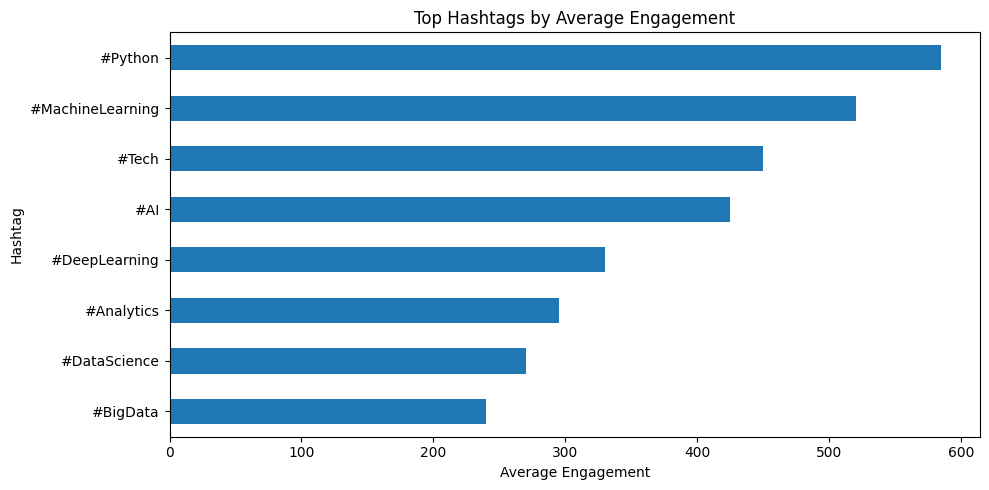

In [15]:
plt.figure(figsize=(10, 5))

hashtag_engagement.sort_values().plot(kind="barh")

plt.title("Top Hashtags by Average Engagement")
plt.xlabel("Average Engagement")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

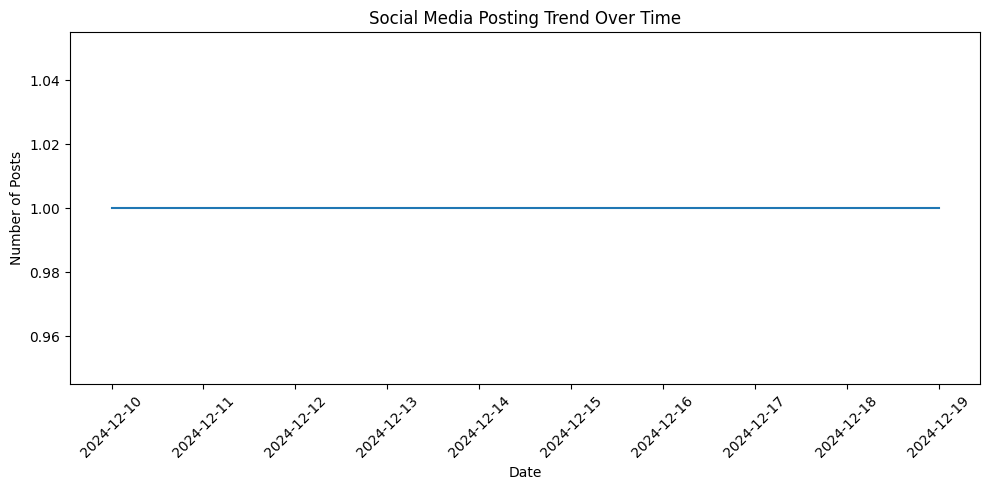

In [16]:
if "date" in df.columns:
    daily_posts = (
        df.dropna(subset=["date"])
        .groupby(df["date"].dt.date)
        .size()
    )

    plt.figure(figsize=(10, 5))
    daily_posts.plot()

    plt.title("Social Media Posting Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Posts")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Final Findings

In [17]:
print("===== SOCIAL MEDIA TREND ANALYSIS SUMMARY =====")

print("\nTop Trending Topics:")
print(trending_topics.head(5))

print("\nTop Public Interest Keywords:")
print(public_interests.head(5))

print("\nHighest Average Engagement Hashtags:")
print(hashtag_engagement.head(5))

print("\nTotal Posts Analyzed:", len(df))
print("Average Likes:", round(df["likes"].mean(), 2))
print("Average Retweets:", round(df["retweets"].mean(), 2))
print("Average Engagement:", round(df["engagement"].mean(), 2))

===== SOCIAL MEDIA TREND ANALYSIS SUMMARY =====

Top Trending Topics:
hashtag
ai                 2
python             2
datascience        1
machinelearning    1
deeplearning       1
Name: count, dtype: int64

Top Public Interest Keywords:
clean_tweet
data               3
learning           3
every              2
python             2
revolutionizing    1
Name: count, dtype: int64

Highest Average Engagement Hashtags:
hashtag
#Python             585.0
#MachineLearning    520.0
#Tech               450.0
#AI                 425.0
#DeepLearning       330.0
Name: engagement, dtype: float64

Total Posts Analyzed: 10
Average Likes: 315.0
Average Retweets: 97.5
Average Engagement: 412.5


## Conclusion

The social media dataset was collected and preprocessed by removing duplicates, handling missing text values, and cleaning tweet content. Hashtag frequency was used to identify trending topics, while keyword frequency helped identify public interests. Likes and retweets were combined to analyze engagement and determine which topics generated stronger audience interaction.

The visualizations provide a clear view of trending topics, public interests, engagement levels, and posting activity, supporting data-driven social media and marketing decisions.